# Experiment 2026-06-30 — linear case, online campaign settings, linear vs nonlinear identifiers

This notebook is a sanity/comparison experiment.

We keep the **linear Laplacian environment** and the paper-style graph/x0 setup:

- Barabási-Albert randomized graph from the repo environment factory;
- `N=15`, `u_bar=0.2`, `omega=1.0`;
- initial opinions are random permutations of evenly spaced values in `[0, 1]`.

But we use the **online single-shot campaign settings** from the previous multitrial experiment:

- campaign `0`: no control, collect passive data;
- campaigns `1..EXPLORATION_CAMPAIGNS`: epsilon-mixed exploration;
- remaining campaigns: full exploitation;
- shorter/frequent campaigns: `NUM_CAMPAIGNS_TOTAL=20`, `T_CAMPAIGN=0.5`, `T_S=0.05`.

The question is:

> In the true linear case, does the linear identifier outperform the nonlinear identifier under the online campaign protocol?

Policies compared:

- `online_linear_euler`: paper-style linear Euler identifier + centrality water filling;
- `online_nonlinear_lambda_mix`: nonlinear identifier + λ-mix centrality policy;
- `oracle_true_v`: true graph centrality baseline;
- `uniform`;
- `no_control`.

The primary objective remains **final average network opinion**. The paper-style consensus-error/suboptimality metrics are included as diagnostics.

In [13]:
from __future__ import annotations

import contextlib
import io
import math
import os
import random
import time
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "opinion_dynamics").exists():
            return p
    raise RuntimeError(
        "Could not find repo root containing opinion_dynamics/. "
        "Run this notebook from the repo or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

# Reuse the already-working nonlinear online runner from the previous experiment.
from opinion_dynamics.experiments.online_single_shot import (
    run_single_shot_online_identification,
)

REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration

Defaults are a medium run:

```text
1 dynamics × 5 topology seeds × 5 initial permutations = 25 trials
```

Each trial runs both learned models plus oracle/uniform/no-control baselines. For a smoke test, set both seed lists to one element.

In [14]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

STUDY_DATE = "2026_06_30"
STUDY_NAME = "linear_online_settings_linear_vs_nonlinear"
RESULTS_DIR = REPO_ROOT / "opinion_dynamics" / "experiments" / "results" / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR)

# True environment dynamics for this sanity check.
DYNAMICS = "laplacian"

# Medium grid. For a smoke test, use [3] and [0].
TOPOLOGY_SEEDS = [3, 4, 5, 6, 7]
INITIAL_PERMUTATION_SEEDS = [0, 1, 2, 3, 4]

# Paper-style graph/control constants.
N_AGENTS = 15
OMEGA = 1.0
U_BAR = 0.2

# Online campaign settings from the previous multitrial experiment.
NUM_CAMPAIGNS_TOTAL = 20
EXPLORATION_CAMPAIGNS = 10
T_CAMPAIGN = 0.5
T_S = 0.05

# Keep the same total controlled budget as the 10-campaign online experiment:
# old controlled budget = 9 controlled campaigns * 0.5 = 4.5.
TOTAL_CONTROLLED_BUDGET = 4.5
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)

LEARNED_POLICY_LAMBDA = 0.70
EPSILON_START = 1.0
EPSILON_END = 0.1

# Identification settings: same budget for both linear and nonlinear identifiers.
LR = 1e-3
L2_LAMBDA = 0.0
FIT_MAX_STEPS = 1_000
FIT_MAE_STOP = 5e-3
FIT_BATCH_SIZE = 256
FIT_CHECK_EVERY = 200
IDENTIFIER_KW_NONLINEAR = {"hidden_dim": 16}

INITIAL_STATE_SEED_BASE = 902_000
TRAIN_SEED_BASE = 812_000
TRIAL_RNG_SEED_BASE = 731_000

KEEP_TRIAL_ARTIFACTS = False
SUPPRESS_FIT_LOGS = True


def make_epsilon_schedule(
    num_campaigns_total: int,
    exploration_campaigns: int,
    eps_start: float = 1.0,
    eps_end: float = 0.1,
) -> list[float]:
    """Campaign 0 is no-control. Campaigns 1..exploration_campaigns linearly decay epsilon."""
    if num_campaigns_total < 1:
        raise ValueError("num_campaigns_total must be >= 1")
    exploration_campaigns = int(min(max(0, exploration_campaigns), num_campaigns_total - 1))
    schedule = [0.0]
    if exploration_campaigns > 0:
        if exploration_campaigns == 1:
            schedule.append(float(eps_start))
        else:
            schedule.extend(np.linspace(float(eps_start), float(eps_end), exploration_campaigns).tolist())
    schedule.extend([0.0] * (num_campaigns_total - len(schedule)))
    return [float(e) for e in schedule]


EPSILON_SCHEDULE = make_epsilon_schedule(
    NUM_CAMPAIGNS_TOTAL,
    EXPLORATION_CAMPAIGNS,
    EPSILON_START,
    EPSILON_END,
)
assert len(EPSILON_SCHEDULE) == NUM_CAMPAIGNS_TOTAL
assert EPSILON_SCHEDULE[0] == 0.0

config_summary = {
    "study_name": STUDY_NAME,
    "dynamics": DYNAMICS,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "n_trials": len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS),
    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
    "exploration_campaigns": EXPLORATION_CAMPAIGNS,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "total_time": NUM_CAMPAIGNS_TOTAL * T_CAMPAIGN,
    "B_campaign": B_CAMPAIGN,
    "total_controlled_budget": (NUM_CAMPAIGNS_TOTAL - 1) * B_CAMPAIGN,
    "u_bar": U_BAR,
    "lambda_mix": LEARNED_POLICY_LAMBDA,
    "epsilon_schedule": EPSILON_SCHEDULE,
    "fit_max_steps": FIT_MAX_STEPS,
    "fit_mae_stop": FIT_MAE_STOP,
}
config_summary

Using DEVICE: cpu
Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_30_linear_online_settings_linear_vs_nonlinear


{'study_name': 'linear_online_settings_linear_vs_nonlinear',
 'dynamics': 'laplacian',
 'topology_seeds': [3, 4, 5, 6, 7],
 'initial_permutation_seeds': [0, 1, 2, 3, 4],
 'n_trials': 25,
 'num_campaigns_total': 20,
 'exploration_campaigns': 10,
 't_campaign': 0.5,
 't_s': 0.05,
 'total_time': 10.0,
 'B_campaign': 0.23684210526315788,
 'total_controlled_budget': 4.5,
 'u_bar': 0.2,
 'lambda_mix': 0.7,
 'epsilon_schedule': [0.0,
  1.0,
  0.9,
  0.8,
  0.7,
  0.6,
  0.5,
  0.3999999999999999,
  0.29999999999999993,
  0.19999999999999996,
  0.1,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'fit_max_steps': 1000,
 'fit_mae_stop': 0.005}

## Shared helpers

The linear identifier is notebook-local and intentionally simple: row-stochastic zero-diagonal `A_hat`, Euler one-step prediction, Adam fitting. The nonlinear identifier is the existing repo runner from `online_single_shot.py`.

In [15]:
def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def as_vector_max_u(max_u: Any, n: int) -> np.ndarray:
    u = np.asarray(max_u, dtype=float)
    if u.ndim == 0:
        return np.full(n, float(u), dtype=float)
    u = u.reshape(-1).astype(float)
    if u.shape != (n,):
        raise ValueError(f"max_u must be scalar or shape ({n},), got {u.shape}")
    return u


def sanitize_centrality(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.sum() < 0:
        v = -v
    v = np.maximum(v, 0.0)
    s = float(v.sum())
    if s <= eps:
        v = np.abs(v)
        s = float(v.sum())
    if s <= eps:
        return np.full_like(v, 1.0 / len(v))
    return v / s


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    return sanitize_centrality(
        compute_eigenvector_centrality(compute_laplacian(np.asarray(A, dtype=float)))
    )


def make_paper_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    x = np.linspace(0.0, 1.0, int(n), dtype=float)
    return rng.permutation(x)


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass
    env.opinions = x0.copy()
    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass


def clone_env_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Any:
    n = int(env_template.num_agents)
    kwargs = dict(
        connectivity_matrix=np.array(env_template.connectivity_matrix, copy=True),
        num_agents=n,
        max_u=np.full(n, float(u_bar), dtype=float),
        desired_opinion=float(omega),
        t_campaign=float(t_campaign),
        t_s=float(t_s),
        dynamics_model=str(dynamics_model if dynamics_model is not None else getattr(env_template, "dynamics_model", "laplacian")),
        control_resistance=np.array(getattr(env_template, "control_resistance", np.zeros(n)), copy=True),
        max_steps=int(getattr(env_template, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env_template, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env_template, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env_template, "normalize_reward", False)),
        terminal_reward=float(getattr(env_template, "terminal_reward", 0.0)),
        terminate_when_converged=bool(terminate_when_converged),
        seed=int(getattr(env_template, "seed", 0)) if getattr(env_template, "seed", None) is not None else None,
    )
    optional_attrs = [
        "fj_lambda", "fj_prejudice", "hk_epsilon", "hk_include_self",
        "nonlinear_beta", "repulsion_epsilon", "repulsion_strength",
    ]
    for attr in optional_attrs:
        if hasattr(env_template, attr):
            kwargs[attr] = getattr(env_template, attr)

    EnvCls = env_template.__class__
    try:
        return EnvCls(**kwargs)
    except TypeError:
        for attr in optional_attrs:
            kwargs.pop(attr, None)
        return EnvCls(**kwargs)


def make_base_env(topology_seed: int) -> Any:
    factory = EnvironmentFactory()
    env = factory.get_randomized_env(seed=int(topology_seed), dynamics_model=DYNAMICS)
    return clone_env_from_template(
        env,
        dynamics_model=DYNAMICS,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )


def pairs_from_intermediate(intermediate_states: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    inter = np.asarray(intermediate_states, dtype=float)
    return inter[:-1], inter[1:]


def normalize_scores(scores: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    s = np.asarray(scores, dtype=float).reshape(-1)
    s = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
    s = np.maximum(s, 0.0)
    m = float(s.max()) if s.size else 0.0
    if m <= eps:
        return np.ones_like(s)
    return s / m


def waterfill_from_scores(scores: np.ndarray, max_u: np.ndarray, budget: float) -> np.ndarray:
    scores = np.asarray(scores, dtype=float).reshape(-1)
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    if scores.shape != max_u.shape:
        raise ValueError(f"scores and max_u shape mismatch: {scores.shape} vs {max_u.shape}")

    u = np.zeros_like(scores, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    if remaining <= 0:
        return u

    order = np.argsort(scores)[::-1]
    for i in order:
        if remaining <= 1e-12:
            break
        if scores[i] <= 0 and np.any(scores > 0):
            break
        assign = min(float(max_u[i]), remaining)
        if assign > 0:
            u[i] = assign
            remaining -= assign
    return u


def uniform_budget_action(max_u: np.ndarray, budget: float) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    n = max_u.size
    u = np.zeros(n, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(n, dtype=bool)
    while remaining > 1e-12 and active.any():
        idxs = np.where(active)[0]
        share = remaining / len(idxs)
        progressed = False
        for i in idxs:
            add = min(share, float(max_u[i] - u[i]))
            if add > 0:
                u[i] += add
                remaining -= add
                progressed = True
            if u[i] >= max_u[i] - 1e-12:
                active[i] = False
        if not progressed:
            break
    return u


def step_env_collect(env: Any, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, np.ndarray]:
    x_next, reward, done, truncated, info = env.step(np.asarray(action, dtype=float))
    inter = info.get("intermediate_states", None)
    if inter is None:
        raise RuntimeError("env.step did not return info['intermediate_states']")
    return np.asarray(x_next, dtype=float), float(reward), bool(done), bool(truncated), np.asarray(inter, dtype=float)

In [16]:
class PaperLinearGraphIdentifier(nn.Module):
    """Row-stochastic zero-diagonal linear Euler identifier."""

    def __init__(self, N: int, s: float, l2_lambda: float = 0.0, zero_diag: bool = True):
        super().__init__()
        self.N = int(N)
        self.s = float(s)
        self.l2_lambda = float(l2_lambda)
        self.zero_diag = bool(zero_diag)
        self.Theta = nn.Parameter(torch.zeros(self.N, self.N))
        nn.init.kaiming_uniform_(self.Theta, a=0.0)
        self.register_buffer("_diag_mask", 1.0 - torch.eye(self.N))
        self.last_fit_info = {}

    def A_hat(self) -> torch.Tensor:
        A = F.softmax(self.Theta, dim=1)
        if self.zero_diag:
            A = A * self._diag_mask
            rs = A.sum(dim=1, keepdim=True)
            rs = torch.where(rs > 0, rs, torch.ones_like(rs))
            A = A / rs
        return A

    def predict_next(self, x: torch.Tensor) -> torch.Tensor:
        A = self.A_hat()
        neighbor_avg = x @ A.T
        return x + self.s * (neighbor_avg - x)

    def loss(self, x: torch.Tensor, x_next: torch.Tensor):
        pred = self.predict_next(x)
        mse = F.mse_loss(pred, x_next)
        l2 = (self.Theta ** 2).sum()
        return mse + self.l2_lambda * l2, {"mse": mse.detach(), "l2": l2.detach()}


def train_paper_linear_identifier(
    model: PaperLinearGraphIdentifier,
    data_x: np.ndarray,
    data_x_next: np.ndarray,
    *,
    lr: float = LR,
    batch_size: int = FIT_BATCH_SIZE,
    max_steps: int = FIT_MAX_STEPS,
    mae_stop: float = FIT_MAE_STOP,
    fit_check_every: int = FIT_CHECK_EVERY,
    device: str = DEVICE,
    suppress_logs: bool = SUPPRESS_FIT_LOGS,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    model.to(device)
    X = torch.tensor(np.asarray(data_x, dtype=np.float32), dtype=torch.float32, device=device)
    Y = torch.tensor(np.asarray(data_x_next, dtype=np.float32), dtype=torch.float32, device=device)
    n = int(X.shape[0])
    if n == 0:
        raise ValueError("No training pairs provided.")

    opt = torch.optim.Adam(model.parameters(), lr=float(lr))
    stop_reason = "max_steps"
    last_mae = float("nan")
    t0 = time.perf_counter()

    for step in range(int(max_steps)):
        idx = torch.randint(0, n, (min(int(batch_size), n),), device=device)
        loss, _ = model.loss(X[idx], Y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % int(fit_check_every) == 0 or step == int(max_steps) - 1:
            with torch.no_grad():
                yhat = model.predict_next(X)
                mae = float((yhat - Y).abs().mean().item())
                last_mae = mae
            if (not suppress_logs) and (step % 2000 == 0 or mae <= mae_stop):
                print(f"[linear-fit] step={step} mae={mae:.5g} n_pairs={n}")
            if mae <= float(mae_stop):
                stop_reason = "mae_stop"
                break

    fit_time = time.perf_counter() - t0
    with torch.no_grad():
        A = model.A_hat().detach().cpu().numpy()
        yhat = model.predict_next(X)
        final_mae = float((yhat - Y).abs().mean().item())
        identity_mae = float((X - Y).abs().mean().item())

    info = {
        "steps_run": int(step + 1),
        "stop_reason": stop_reason,
        "train_mae": final_mae,
        "identity_mae": identity_mae,
        "model_over_identity": final_mae / (identity_mae + 1e-12),
        "n_pairs": n,
        "fit_time_sec": float(fit_time),
    }
    model.last_fit_info = info
    return A, info

## Rollout routines

The linear and nonlinear learned policies use the same online campaign protocol.

For the linear model, the learned score is:

```text
score_i = centrality_i(A_hat) * |omega - x_i|
```

For the nonlinear model, the existing runner uses:

```text
M_lambda(x) = (1-lambda) A_hat + lambda (A_hat * alpha(x))
score_i = centrality_i(M_lambda(x)) * |omega - x_i|
```

In [17]:
def rollout_fixed_policy_single_shot(
    env_template: Any,
    x0: np.ndarray,
    *,
    policy_name: str,
    v_policy: Optional[np.ndarray] = None,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    B_campaign: float = B_CAMPAIGN,
    zero_first_campaign: bool = True,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []

    max_u = as_vector_max_u(env.max_u, env.num_agents)

    for k in range(int(num_campaigns_total)):
        if policy_name == "no_control" or (zero_first_campaign and k == 0):
            u = np.zeros(env.num_agents, dtype=float)
        elif policy_name == "uniform":
            u = uniform_budget_action(max_u, B_campaign)
        elif policy_name == "oracle_true_v":
            if v_policy is None:
                raise ValueError("v_policy is required for oracle_true_v")
            u, _ = centrality_based_continuous_control(env, B_campaign, v=v_policy)
        else:
            raise ValueError(f"Unknown policy_name={policy_name}")

        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

        if done or trunc:
            break

    return {
        "policy": policy_name,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
    }


def exploratory_linear_action(
    model: Optional[PaperLinearGraphIdentifier],
    x: np.ndarray,
    *,
    desired_opinion: float,
    max_u: np.ndarray,
    budget: float,
    epsilon: float,
    rng: np.random.Generator,
    device: str = DEVICE,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    x = np.asarray(x, dtype=float).reshape(-1)
    random_scores = rng.random(x.shape[0])

    if model is None:
        learned_scores = np.zeros_like(random_scores)
        v_hat = np.full_like(random_scores, 1.0 / len(random_scores), dtype=float)
        A_hat = np.zeros((len(random_scores), len(random_scores)), dtype=float)
    else:
        model.to(device)
        model.eval()
        with torch.no_grad():
            A_hat = model.A_hat().detach().cpu().numpy()
        v_hat = centrality_from_A(A_hat)
        learned_scores = v_hat * np.abs(float(desired_opinion) - x)

    eps = float(np.clip(epsilon, 0.0, 1.0))
    combined_scores = (1.0 - eps) * normalize_scores(learned_scores) + eps * normalize_scores(random_scores)
    action = waterfill_from_scores(combined_scores, max_u=max_u, budget=budget)

    info = {
        "epsilon": eps,
        "learned_scores": learned_scores,
        "random_scores": random_scores,
        "combined_scores": combined_scores,
        "learned_centrality": v_hat,
        "learned_matrix": A_hat,
    }
    return action, info


def run_single_shot_online_linear_identifier(
    env_template: Any,
    *,
    x0: np.ndarray,
    topology_seed: int,
    initial_seed: int,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    B_campaign: float = B_CAMPAIGN,
    epsilon_schedule: Iterable[float] = EPSILON_SCHEDULE,
    lr: float = LR,
    l2_lambda: float = L2_LAMBDA,
    fit_max_steps: int = FIT_MAX_STEPS,
    fit_mae_stop: float = FIT_MAE_STOP,
    fit_batch_size: int = FIT_BATCH_SIZE,
    fit_check_every: int = FIT_CHECK_EVERY,
    device: str = DEVICE,
    rng_seed: int = 0,
) -> Dict[str, Any]:
    env = clone_env_from_template(
        env_template,
        dynamics_model=DYNAMICS,
        t_campaign=t_campaign,
        t_s=t_s,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )
    env.reset()
    set_initial_state(env, x0)

    N = int(env.num_agents)
    max_u = as_vector_max_u(env.max_u, N)

    train_seed = TRAIN_SEED_BASE + 10_000 * int(topology_seed) + 100 * int(initial_seed)
    set_global_seed(train_seed)
    rng = np.random.default_rng(int(rng_seed))

    eps_schedule = list(epsilon_schedule)
    if len(eps_schedule) < int(num_campaigns_total):
        eps_schedule = eps_schedule + [0.0] * (int(num_campaigns_total) - len(eps_schedule))

    state = np.asarray(x0, dtype=float).reshape(N)
    states = [state.copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []
    policy_infos = []
    A_hats = []
    v_hats = []
    fit_infos = []
    buf_x, buf_y = [], []
    model: Optional[PaperLinearGraphIdentifier] = None

    for k in range(int(num_campaigns_total)):
        if k == 0:
            action = np.zeros(N, dtype=float)
            policy_info = {"epsilon": np.nan, "phase": "passive_initial"}
        else:
            eps_k = float(eps_schedule[k])
            action, policy_info = exploratory_linear_action(
                model,
                state,
                desired_opinion=float(env.desired_opinion),
                max_u=max_u,
                budget=float(B_campaign),
                epsilon=eps_k,
                rng=rng,
                device=device,
            )
            policy_info["phase"] = "explore" if eps_k > 0 else "exploit"

        x_next, r, done, trunc, inter = step_env_collect(env, action)
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

        actions.append(action.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        policy_infos.append(policy_info)

        if model is None:
            model = PaperLinearGraphIdentifier(N=N, s=float(env.t_s), l2_lambda=l2_lambda, zero_diag=True)

        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)
        A_hat, fit_info = train_paper_linear_identifier(
            model,
            X,
            Y,
            lr=lr,
            batch_size=fit_batch_size,
            max_steps=fit_max_steps,
            mae_stop=fit_mae_stop,
            fit_check_every=fit_check_every,
            device=device,
            suppress_logs=SUPPRESS_FIT_LOGS,
        )
        v_hat = centrality_from_A(A_hat)

        fit_info = dict(fit_info, campaign=int(k))
        fit_infos.append(fit_info)
        A_hats.append(np.asarray(A_hat, dtype=float).copy())
        v_hats.append(v_hat.copy())

        state = np.asarray(x_next, dtype=float).copy()

        if done or trunc:
            break

    return {
        "policy": "online_linear_euler",
        "model": model,
        "x0": np.asarray(x0, dtype=float),
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "policy_infos": policy_infos,
        "A_hats": A_hats,
        "v_hats": v_hats,
        "fit_infos": fit_infos,
        "epsilon_schedule": np.asarray(eps_schedule[: len(actions)], dtype=float),
    }


def wrap_nonlinear_rollout(out: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(out)
    out["policy"] = "online_nonlinear_lambda_mix"
    out["boundary_times"] = np.arange(len(out["states"]), dtype=float) * float(T_CAMPAIGN)
    return out

## Metrics and table helpers

In [18]:
POLICY_LINEAR = "online_linear_euler"
POLICY_NONLINEAR = "online_nonlinear_lambda_mix"
POLICY_ORACLE = "oracle_true_v"
POLICY_UNIFORM = "uniform"
POLICY_NOCONTROL = "no_control"

POLICY_LABELS = {
    POLICY_LINEAR: "online linear Euler",
    POLICY_NONLINEAR: "online nonlinear λ-mix",
    POLICY_ORACLE: "oracle true-v",
    POLICY_UNIFORM: "uniform",
    POLICY_NOCONTROL: "no control",
}

PLOT_POLICIES = [POLICY_ORACLE, POLICY_LINEAR, POLICY_NONLINEAR, POLICY_UNIFORM, POLICY_NOCONTROL]


def final_consensus_error(states: np.ndarray, v_true: np.ndarray, omega: float = OMEGA) -> float:
    final_state = np.asarray(states, dtype=float)[-1]
    consensus_value = float(np.asarray(v_true, dtype=float).reshape(-1) @ final_state)
    return abs(float(omega) - consensus_value)


def rollout_mean_end(out: Dict[str, Any]) -> float:
    return float(np.asarray(out["states"], dtype=float)[-1].mean())


def trajectory_rows(
    *,
    topology_seed: int,
    initial_seed: int,
    policy: str,
    rollout: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    states = np.asarray(rollout["states"], dtype=float)
    times = np.asarray(rollout["boundary_times"], dtype=float)
    trial_id = f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}"
    for idx, (t, x) in enumerate(zip(times, states)):
        rows.append({
            "dynamics": DYNAMICS,
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "trial_id": trial_id,
            "policy": policy,
            "policy_label": POLICY_LABELS.get(policy, policy),
            "boundary_index": int(idx),
            "time": float(t),
            "mean_opinion": float(np.mean(x)),
            "min_opinion": float(np.min(x)),
            "max_opinion": float(np.max(x)),
            "consensus_value": float(np.asarray(v_true).reshape(-1) @ np.asarray(x).reshape(-1)),
        })
    return rows


def learned_identifier_metrics(
    *,
    model_name: str,
    learned: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    A_hats = learned.get("A_hats", [])
    if model_name == POLICY_NONLINEAR:
        v_hats = learned.get("v_hats_lambda", []) or learned.get("v_hats_static", [])
    else:
        v_hats = learned.get("v_hats", [])

    if not A_hats or not v_hats:
        return {}

    A_final = np.asarray(A_hats[-1], dtype=float)
    v_final = np.asarray(v_hats[-1], dtype=float)
    v_errs = [float(np.sum(np.abs(np.asarray(vh, dtype=float) - v_true))) for vh in v_hats]

    last_fit = learned["fit_infos"][-1]
    return {
        "max_v_L1": float(max(v_errs)),
        "final_v_L1": float(np.sum(np.abs(v_final - v_true))),
        "A_MAE_final": float(np.mean(np.abs(A_final - A_true))),
        "A_Fro_final": float(np.linalg.norm(A_final - A_true, ord="fro")),
        "final_train_mae": float(last_fit["train_mae"]),
        "final_identity_mae": float(last_fit["identity_mae"]),
        "final_model_over_identity": float(last_fit["model_over_identity"]),
        "final_n_pairs": int(last_fit["n_pairs"]),
        "total_fit_time_sec": float(sum(info.get("fit_time_sec", info.get("fit_elapsed_s", 0.0)) for info in learned["fit_infos"])),
    }


def summarize_learned_trial(
    *,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    oracle: Dict[str, Any],
    uniform: Dict[str, Any],
    no_control: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    delta = final_consensus_error(learned["states"], v_true)
    delta_oracle = final_consensus_error(oracle["states"], v_true)
    delta_uniform = final_consensus_error(uniform["states"], v_true)
    delta_noc = final_consensus_error(no_control["states"], v_true)

    mean_end = rollout_mean_end(learned)
    mean_oracle = rollout_mean_end(oracle)
    mean_uniform = rollout_mean_end(uniform)
    mean_noc = rollout_mean_end(no_control)

    row = {
        "dynamics": DYNAMICS,
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "trial_id": f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}",
        "model": model_name,
        "model_label": POLICY_LABELS[model_name],
        "delta": float(delta),
        "delta_oracle": float(delta_oracle),
        "delta_uniform": float(delta_uniform),
        "delta_nocontrol": float(delta_noc),
        "suboptimality_vs_oracle_delta": float(delta - delta_oracle),
        "model_minus_uniform_delta": float(delta - delta_uniform),
        "model_minus_nocontrol_delta": float(delta - delta_noc),
        "mean_end": float(mean_end),
        "mean_oracle_end": float(mean_oracle),
        "mean_uniform_end": float(mean_uniform),
        "mean_nocontrol_end": float(mean_noc),
        "model_minus_oracle_mean_end": float(mean_end - mean_oracle),
        "model_minus_uniform_mean_end": float(mean_end - mean_uniform),
        "model_minus_nocontrol_mean_end": float(mean_end - mean_noc),
    }
    row.update(learned_identifier_metrics(model_name=model_name, learned=learned, A_true=A_true, v_true=v_true))
    return row


def fit_rows_from_rollout(
    *,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    if model_name == POLICY_NONLINEAR:
        v_hats = learned.get("v_hats_lambda", []) or learned.get("v_hats_static", [])
    else:
        v_hats = learned.get("v_hats", [])

    for idx, info in enumerate(learned.get("fit_infos", [])):
        row = {
            "dynamics": DYNAMICS,
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "trial_id": f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}",
            "model": model_name,
            "model_label": POLICY_LABELS[model_name],
        }
        row.update(info)
        if idx < len(v_hats):
            row["v_L1_to_true"] = float(np.sum(np.abs(np.asarray(v_hats[idx], dtype=float) - v_true)))
        rows.append(row)
    return rows

## Run the study

This is the expensive cell. It compares both learned identifiers on the same topology and initial opinion vector within each trial.

In [19]:
summary_rows = []
trajectory_rows_all = []
fit_rows_all = []
failed_rows = []
artifacts = {} if KEEP_TRIAL_ARTIFACTS else None

t_start = time.perf_counter()

for topology_seed in TOPOLOGY_SEEDS:
    base_env = make_base_env(topology_seed)
    A_true = np.asarray(base_env.connectivity_matrix, dtype=float)
    v_true = centrality_from_A(A_true)

    for initial_seed in INITIAL_PERMUTATION_SEEDS:
        trial_id = f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}"
        print(f"Running {trial_id} ...")

        try:
            x0 = make_paper_initial_opinions(base_env.num_agents, initial_seed)

            oracle = rollout_fixed_policy_single_shot(
                base_env, x0, policy_name=POLICY_ORACLE, v_policy=v_true
            )
            uniform = rollout_fixed_policy_single_shot(
                base_env, x0, policy_name=POLICY_UNIFORM
            )
            no_control = rollout_fixed_policy_single_shot(
                base_env, x0, policy_name=POLICY_NOCONTROL
            )

            rng_seed = TRIAL_RNG_SEED_BASE + 10_000 * int(topology_seed) + 100 * int(initial_seed)

            learned_linear = run_single_shot_online_linear_identifier(
                base_env,
                x0=x0,
                topology_seed=topology_seed,
                initial_seed=initial_seed,
                rng_seed=rng_seed,
            )

            learned_nonlinear = run_single_shot_online_identification(
                base_env,
                x0=x0,
                random_initial_opinions=False,
                num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                t_campaign=T_CAMPAIGN,
                t_s=T_S,
                B_campaign=B_CAMPAIGN,
                lambda_mix=LEARNED_POLICY_LAMBDA,
                exploration_campaigns=EXPLORATION_CAMPAIGNS,
                epsilon_schedule=EPSILON_SCHEDULE,
                lr=LR,
                l2_lambda=L2_LAMBDA,
                fit_max_steps=FIT_MAX_STEPS,
                fit_mae_stop=FIT_MAE_STOP,
                fit_batch_size=FIT_BATCH_SIZE,
                fit_check_every=FIT_CHECK_EVERY,
                identifier_kwargs=IDENTIFIER_KW_NONLINEAR,
                device=DEVICE,
                rng_seed=rng_seed,
                suppress_fit_logs=SUPPRESS_FIT_LOGS,
            )
            learned_nonlinear = wrap_nonlinear_rollout(learned_nonlinear)

            for policy, rollout in [
                (POLICY_ORACLE, oracle),
                (POLICY_LINEAR, learned_linear),
                (POLICY_NONLINEAR, learned_nonlinear),
                (POLICY_UNIFORM, uniform),
                (POLICY_NOCONTROL, no_control),
            ]:
                trajectory_rows_all.extend(
                    trajectory_rows(
                        topology_seed=topology_seed,
                        initial_seed=initial_seed,
                        policy=policy,
                        rollout=rollout,
                        v_true=v_true,
                    )
                )

            summary_rows.append(
                summarize_learned_trial(
                    topology_seed=topology_seed,
                    initial_seed=initial_seed,
                    model_name=POLICY_LINEAR,
                    learned=learned_linear,
                    oracle=oracle,
                    uniform=uniform,
                    no_control=no_control,
                    A_true=A_true,
                    v_true=v_true,
                )
            )
            summary_rows.append(
                summarize_learned_trial(
                    topology_seed=topology_seed,
                    initial_seed=initial_seed,
                    model_name=POLICY_NONLINEAR,
                    learned=learned_nonlinear,
                    oracle=oracle,
                    uniform=uniform,
                    no_control=no_control,
                    A_true=A_true,
                    v_true=v_true,
                )
            )

            fit_rows_all.extend(
                fit_rows_from_rollout(
                    topology_seed=topology_seed,
                    initial_seed=initial_seed,
                    model_name=POLICY_LINEAR,
                    learned=learned_linear,
                    v_true=v_true,
                )
            )
            fit_rows_all.extend(
                fit_rows_from_rollout(
                    topology_seed=topology_seed,
                    initial_seed=initial_seed,
                    model_name=POLICY_NONLINEAR,
                    learned=learned_nonlinear,
                    v_true=v_true,
                )
            )

            if artifacts is not None:
                artifacts[trial_id] = {
                    "oracle": oracle,
                    "uniform": uniform,
                    "no_control": no_control,
                    "learned_linear": learned_linear,
                    "learned_nonlinear": learned_nonlinear,
                    "A_true": A_true,
                    "v_true": v_true,
                    "x0": x0,
                }

        except Exception as exc:
            import traceback
            failed_rows.append({
                "trial_id": trial_id,
                "topology_seed": int(topology_seed),
                "initial_seed": int(initial_seed),
                "error": repr(exc),
                "traceback": traceback.format_exc(),
            })
            print("FAILED:", trial_id, repr(exc))

elapsed = time.perf_counter() - t_start
print(f"Done in {elapsed:.1f}s")

summary_df = pd.DataFrame(summary_rows)
trajectory_df = pd.DataFrame(trajectory_rows_all)
fit_df = pd.DataFrame(fit_rows_all)
failed_df = pd.DataFrame(failed_rows)

display(summary_df.head())
if not failed_df.empty:
    display(failed_df[["trial_id", "error"]])

Running laplacian|topo=3|init=0 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running laplacian|topo=3|init=1 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running laplacian|topo=3|init=2 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running laplacian|topo=3|init=3 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running laplacian|topo=3|init=4 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear f

,dynamics,topology_seed,initial_seed,trial_id,model,model_label,delta,delta_oracle,delta_uniform,delta_nocontrol,suboptimality_vs_oracle_delta,model_minus_uniform_delta,model_minus_nocontrol_delta,mean_end,mean_oracle_end,mean_uniform_end,mean_nocontrol_end,model_minus_oracle_mean_end,model_minus_uniform_mean_end,model_minus_nocontrol_mean_end,max_v_L1,final_v_L1,A_MAE_final,A_Fro_final,final_train_mae,final_identity_mae,final_model_over_identity,final_n_pairs,total_fit_time_sec
0,laplacian,3,0,laplacian|topo=3|init=0,online_linear_euler,online linear Euler,0.364143,0.284452,0.377892,0.511324,0.079690,-0.013749,-0.147181,0.635299,0.707529,0.622291,0.488924,-0.072230,0.013008,0.146375,0.504691,0.502895,0.101367,2.140938,0.001222,0.001906,0.641221,200,0.150265
1,laplacian,3,0,laplacian|topo=3|init=0,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.372127,0.284452,0.377892,0.511324,0.087674,-0.005765,-0.139197,0.626458,0.707529,0.622291,0.488924,-0.081071,0.004167,0.137534,0.531656,0.531218,0.099797,2.128078,0.000920,0.001849,0.497861,200,0.458910
2,laplacian,3,1,laplacian|topo=3|init=1,online_linear_euler,online linear Euler,0.403273,0.301359,0.407353,0.551187,0.101914,-0.004081,-0.147915,0.599779,0.690454,0.592835,0.449068,-0.090675,0.006944,0.150711,0.519776,0.519088,0.101346,2.140964,0.001145,0.001904,0.601572,200,0.018041
3,laplacian,3,1,laplacian|topo=3|init=1,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.412982,0.301359,0.407353,0.551187,0.111624,0.005629,-0.138205,0.586782,0.690454,0.592835,0.449068,-0.103672,-0.006053,0.137714,0.530718,0.529894,0.101112,2.163397,0.000696,0.001869,0.372326,200,0.405581
4,laplacian,3,2,laplacian|topo=3|init=2,online_linear_euler,online linear Euler,0.381670,0.282563,0.374835,0.507187,0.099108,0.006836,-0.125516,0.614761,0.709153,0.624507,0.491922,-0.094392,-0.009746,0.122838,0.515543,0.515543,0.099069,2.123441,0.001338,0.001874,0.714058,200,0.126471


## Save result tables

In [20]:
summary_path = RESULTS_DIR / "linear_vs_nonlinear_summary.csv"
trajectory_path = RESULTS_DIR / "linear_vs_nonlinear_trajectories.csv"
fit_path = RESULTS_DIR / "linear_vs_nonlinear_fit_diagnostics.csv"
failed_path = RESULTS_DIR / "linear_vs_nonlinear_failed_trials.csv"

summary_df.to_csv(summary_path, index=False)
trajectory_df.to_csv(trajectory_path, index=False)
fit_df.to_csv(fit_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Saved:")
print(" ", summary_path)
print(" ", trajectory_path)
print(" ", fit_path)
print(" ", failed_path)

Saved:
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_30_linear_online_settings_linear_vs_nonlinear\linear_vs_nonlinear_summary.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_30_linear_online_settings_linear_vs_nonlinear\linear_vs_nonlinear_trajectories.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_30_linear_online_settings_linear_vs_nonlinear\linear_vs_nonlinear_fit_diagnostics.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_30_linear_online_settings_linear_vs_nonlinear\linear_vs_nonlinear_failed_trials.csv


## Main result table

Primary metric: **final average network opinion**.

The most important signed comparison is:

```text
model_minus_uniform_mean_end
```

Positive means the learned model beats uniform on the primary metric.

In [21]:
compact = (
    summary_df
    .groupby(["model", "model_label"])
    .agg(
        n_trials=("trial_id", "count"),
        mean_end=("mean_end", "mean"),
        mean_oracle_end=("mean_oracle_end", "mean"),
        mean_uniform_end=("mean_uniform_end", "mean"),
        mean_nocontrol_end=("mean_nocontrol_end", "mean"),
        model_minus_uniform_mean_end=("model_minus_uniform_mean_end", "mean"),
        model_minus_oracle_mean_end=("model_minus_oracle_mean_end", "mean"),
        model_minus_nocontrol_mean_end=("model_minus_nocontrol_mean_end", "mean"),
        win_rate_vs_uniform_mean=("model_minus_uniform_mean_end", lambda s: float((s > 0).mean())),
        delta=("delta", "mean"),
        delta_oracle=("delta_oracle", "mean"),
        suboptimality_vs_oracle_delta=("suboptimality_vs_oracle_delta", "mean"),
        model_minus_uniform_delta=("model_minus_uniform_delta", "mean"),
        max_v_L1=("max_v_L1", "mean"),
        final_v_L1=("final_v_L1", "mean"),
        A_MAE_final=("A_MAE_final", "mean"),
        final_model_over_identity=("final_model_over_identity", "mean"),
        total_fit_time_sec=("total_fit_time_sec", "mean"),
    )
    .reset_index()
)

display(compact.round(5))

,model,model_label,n_trials,mean_end,mean_oracle_end,mean_uniform_end,mean_nocontrol_end,model_minus_uniform_mean_end,model_minus_oracle_mean_end,model_minus_nocontrol_mean_end,win_rate_vs_uniform_mean,delta,delta_oracle,suboptimality_vs_oracle_delta,model_minus_uniform_delta,max_v_L1,final_v_L1,A_MAE_final,final_model_over_identity,total_fit_time_sec
0,online_linear_euler,online linear Euler,25,0.62528,0.75486,0.61819,0.48338,0.00709,-0.12957,0.14191,0.64,0.37384,0.23237,0.14147,-0.00828,0.66094,0.65998,0.10507,0.64939,0.22353
1,online_nonlinear_lambda_mix,online nonlinear λ-mix,25,0.62587,0.75486,0.61819,0.48338,0.00768,-0.12898,0.14250,0.52,0.37479,0.23237,0.14242,-0.00733,0.65997,0.65856,0.10550,0.54597,0.63101


## Average-opinion trajectories

These are the main plots. They show how oracle, linear model, nonlinear model, uniform, and no-control evolve over the same trial grid.

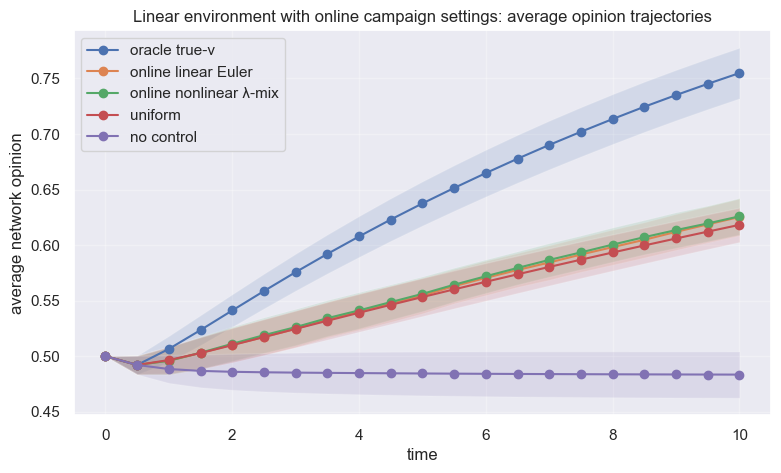

In [22]:
def plot_mean_trajectories(metric: str = "mean_opinion") -> None:
    df = trajectory_df[trajectory_df["policy"].isin(PLOT_POLICIES)].copy()

    fig, ax = plt.subplots(figsize=(9, 5))
    for policy in PLOT_POLICIES:
        sub = df[df["policy"] == policy]
        grouped = sub.groupby("time")[metric]
        mean = grouped.mean()
        count = grouped.count()
        sem = grouped.std(ddof=1) / np.sqrt(count.clip(lower=1))
        sem = sem.fillna(0.0)

        x = mean.index.to_numpy(dtype=float)
        y = mean.to_numpy(dtype=float)
        e = sem.to_numpy(dtype=float)

        ax.plot(x, y, marker="o", label=POLICY_LABELS.get(policy, policy))
        ax.fill_between(x, y - 1.96 * e, y + 1.96 * e, alpha=0.15)

    ax.set_title("Linear environment with online campaign settings: average opinion trajectories")
    ax.set_xlabel("time")
    ax.set_ylabel("average network opinion")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.show()


plot_mean_trajectories("mean_opinion")

## Learned model vs uniform

Positive values mean the learned online model beats uniform on final average opinion.

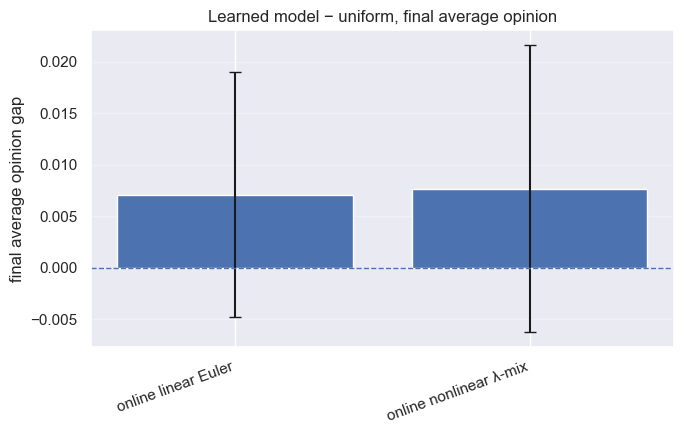

,model,model_label,mean,std,count,sem,ci95
0,online_linear_euler,online linear Euler,0.00709,0.03038,25,0.00608,0.01191
1,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.00768,0.03565,25,0.00713,0.01397


In [23]:
def mean_sem_df(df: pd.DataFrame, value_col: str, group_cols: list[str]) -> pd.DataFrame:
    out = (
        df.groupby(group_cols)[value_col]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    out["sem"] = out["std"] / np.sqrt(out["count"].clip(lower=1))
    out["ci95"] = 1.96 * out["sem"].fillna(0.0)
    return out


gap_df = mean_sem_df(summary_df, "model_minus_uniform_mean_end", ["model", "model_label"])
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(gap_df))
ax.bar(x, gap_df["mean"], yerr=gap_df["ci95"], capsize=4)
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(gap_df["model_label"], rotation=20, ha="right")
ax.set_ylabel("final average opinion gap")
ax.set_title("Learned model − uniform, final average opinion")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(gap_df.round(5))

## Linear vs nonlinear, paired by trial

This table compares the two learned models directly on the same graph and same initial opinions.

In [24]:
paired = summary_df.pivot_table(
    index=["trial_id", "topology_seed", "initial_seed"],
    columns="model",
    values=[
        "mean_end",
        "model_minus_uniform_mean_end",
        "delta",
        "suboptimality_vs_oracle_delta",
        "final_model_over_identity",
        "final_v_L1",
        "A_MAE_final",
    ],
)

paired.columns = [f"{a}__{b}" for a, b in paired.columns]
paired = paired.reset_index()

paired["linear_minus_nonlinear_mean_end"] = paired[f"mean_end__{POLICY_LINEAR}"] - paired[f"mean_end__{POLICY_NONLINEAR}"]
paired["linear_minus_nonlinear_vs_uniform_gap"] = paired[f"model_minus_uniform_mean_end__{POLICY_LINEAR}"] - paired[f"model_minus_uniform_mean_end__{POLICY_NONLINEAR}"]
paired["linear_better_than_nonlinear"] = paired["linear_minus_nonlinear_mean_end"] > 0

paired_summary = pd.DataFrame([{
    "n_trials": paired["trial_id"].count(),
    "linear_minus_nonlinear_mean_end": paired["linear_minus_nonlinear_mean_end"].mean(),
    "linear_minus_nonlinear_vs_uniform_gap": paired["linear_minus_nonlinear_vs_uniform_gap"].mean(),
    "linear_win_rate": paired["linear_better_than_nonlinear"].mean(),
}])

display(paired_summary.round(5))
display(paired.head().round(5))

,n_trials,linear_minus_nonlinear_mean_end,linear_minus_nonlinear_vs_uniform_gap,linear_win_rate
0,25,-0.00059,-0.00059,0.6


,trial_id,topology_seed,initial_seed,A_MAE_final__online_linear_euler,A_MAE_final__online_nonlinear_lambda_mix,delta__online_linear_euler,delta__online_nonlinear_lambda_mix,final_model_over_identity__online_linear_euler,final_model_over_identity__online_nonlinear_lambda_mix,final_v_L1__online_linear_euler,final_v_L1__online_nonlinear_lambda_mix,mean_end__online_linear_euler,mean_end__online_nonlinear_lambda_mix,model_minus_uniform_mean_end__online_linear_euler,model_minus_uniform_mean_end__online_nonlinear_lambda_mix,suboptimality_vs_oracle_delta__online_linear_euler,suboptimality_vs_oracle_delta__online_nonlinear_lambda_mix,linear_minus_nonlinear_mean_end,linear_minus_nonlinear_vs_uniform_gap,linear_better_than_nonlinear
0,laplacian|topo=3|init=0,3,0,0.10137,0.09980,0.36414,0.37213,0.64122,0.49786,0.50290,0.53122,0.63530,0.62646,0.01301,0.00417,0.07969,0.08767,0.00884,0.00884,True
1,laplacian|topo=3|init=1,3,1,0.10135,0.10111,0.40327,0.41298,0.60157,0.37233,0.51909,0.52989,0.59978,0.58678,0.00694,-0.00605,0.10191,0.11162,0.01300,0.01300,True
2,laplacian|topo=3|init=2,3,2,0.09907,0.09726,0.38167,0.34937,0.71406,0.52057,0.51554,0.46315,0.61476,0.64558,-0.00975,0.02108,0.09911,0.06680,-0.03082,-0.03082,False
3,laplacian|topo=3|init=3,3,3,0.09800,0.09777,0.40098,0.41862,0.53784,0.50060,0.52215,0.49971,0.60030,0.58410,0.01276,-0.00343,0.08916,0.10680,0.01619,0.01619,True
4,laplacian|topo=3|init=4,3,4,0.10088,0.09995,0.35070,0.35895,0.36644,0.42839,0.50093,0.49693,0.64603,0.64092,0.02899,0.02389,0.06434,0.07259,0.00510,0.00510,True


## Identification diagnostics

The linear environment should favor the linear identifier. The nonlinear identifier can still fit one-step transitions, but it has extra degrees of freedom, so centrality recovery may be worse.

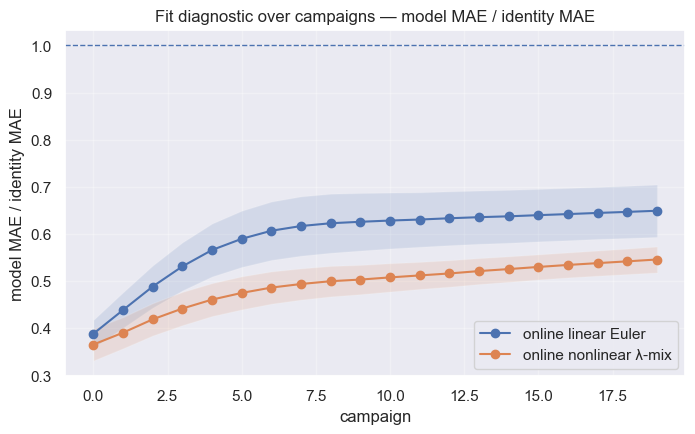

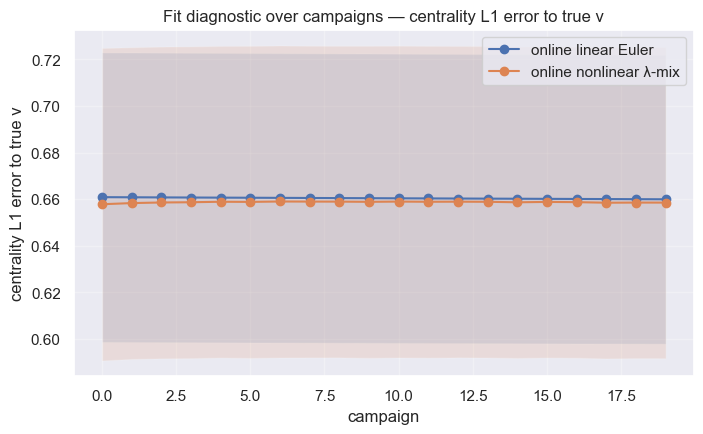

In [25]:
if not fit_df.empty:
    for metric, ylabel in [
        ("model_over_identity", "model MAE / identity MAE"),
        ("v_L1_to_true", "centrality L1 error to true v"),
    ]:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for model, label in [(POLICY_LINEAR, POLICY_LABELS[POLICY_LINEAR]), (POLICY_NONLINEAR, POLICY_LABELS[POLICY_NONLINEAR])]:
            sub = fit_df[fit_df["model"] == model].copy()
            if "campaign" not in sub.columns or metric not in sub.columns:
                continue
            grouped = sub.groupby("campaign")[metric]
            mean = grouped.mean()
            count = grouped.count()
            sem = grouped.std(ddof=1) / np.sqrt(count.clip(lower=1))
            sem = sem.fillna(0.0)

            x = mean.index.to_numpy(dtype=float)
            y = mean.to_numpy(dtype=float)
            e = sem.to_numpy(dtype=float)
            ax.plot(x, y, marker="o", label=label)
            ax.fill_between(x, y - 1.96 * e, y + 1.96 * e, alpha=0.15)

        if metric == "model_over_identity":
            ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_title(f"Fit diagnostic over campaigns — {ylabel}")
        ax.set_xlabel("campaign")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        plt.show()
else:
    print("fit_df is empty.")

## Topology × initial-state heatmaps

These show where each model beats or loses to uniform.

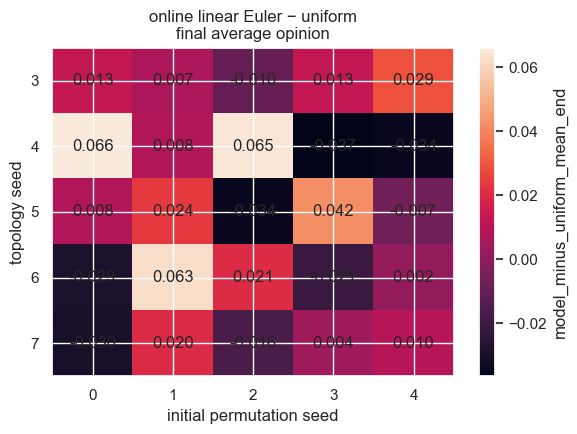

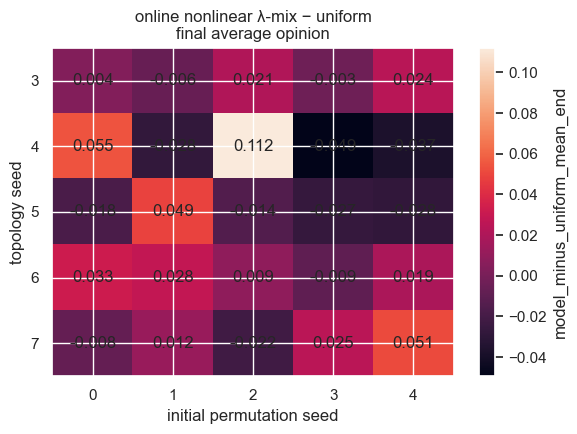

In [26]:
def plot_heatmap_for_model(model: str, value_col: str = "model_minus_uniform_mean_end") -> None:
    sub = summary_df[summary_df["model"] == model].copy()
    table = sub.pivot(index="topology_seed", columns="initial_seed", values=value_col)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    im = ax.imshow(table.values, aspect="auto")
    ax.set_title(f"{POLICY_LABELS[model]} − uniform\nfinal average opinion")
    ax.set_xlabel("initial permutation seed")
    ax.set_ylabel("topology seed")
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            val = table.values[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, label=value_col)
    plt.tight_layout()
    plt.show()


plot_heatmap_for_model(POLICY_LINEAR)
plot_heatmap_for_model(POLICY_NONLINEAR)

## Selected trial diagnostic

Use this to inspect a particular graph/initial condition if aggregate results look odd.

Selected trial: laplacian|topo=3|init=0


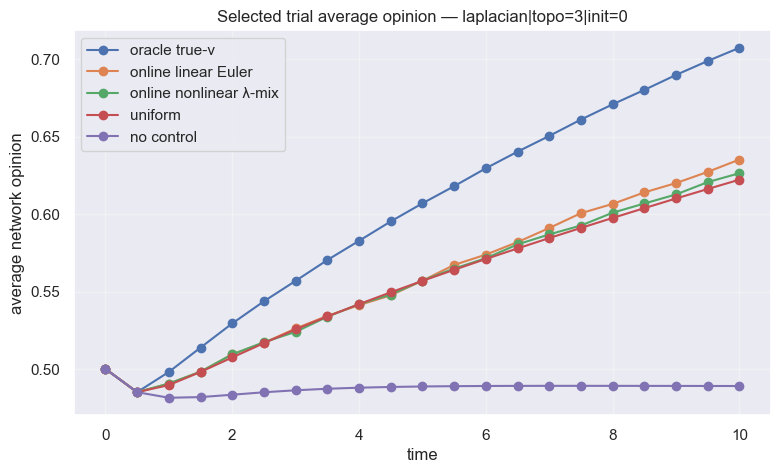

,dynamics,topology_seed,initial_seed,trial_id,model,model_label,delta,delta_oracle,delta_uniform,delta_nocontrol,suboptimality_vs_oracle_delta,model_minus_uniform_delta,model_minus_nocontrol_delta,mean_end,mean_oracle_end,mean_uniform_end,mean_nocontrol_end,model_minus_oracle_mean_end,model_minus_uniform_mean_end,model_minus_nocontrol_mean_end,max_v_L1,final_v_L1,A_MAE_final,A_Fro_final,final_train_mae,final_identity_mae,final_model_over_identity,final_n_pairs,total_fit_time_sec
0,laplacian,3,0,laplacian|topo=3|init=0,online_linear_euler,online linear Euler,0.36414,0.28445,0.37789,0.51132,0.07969,-0.01375,-0.14718,0.63530,0.70753,0.62229,0.48892,-0.07223,0.01301,0.14637,0.50469,0.50290,0.10137,2.14094,0.00122,0.00191,0.64122,200,0.15027
1,laplacian,3,0,laplacian|topo=3|init=0,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.37213,0.28445,0.37789,0.51132,0.08767,-0.00577,-0.13920,0.62646,0.70753,0.62229,0.48892,-0.08107,0.00417,0.13753,0.53166,0.53122,0.09980,2.12808,0.00092,0.00185,0.49786,200,0.45891


: 

In [ ]:
SELECT_TOPOLOGY_SEED = TOPOLOGY_SEEDS[0]
SELECT_INITIAL_SEED = INITIAL_PERMUTATION_SEEDS[0]
SELECT_TRIAL_ID = f"{DYNAMICS}|topo={SELECT_TOPOLOGY_SEED}|init={SELECT_INITIAL_SEED}"
print("Selected trial:", SELECT_TRIAL_ID)

sel = trajectory_df[trajectory_df["trial_id"] == SELECT_TRIAL_ID].copy()

fig, ax = plt.subplots(figsize=(9, 5))
for policy in PLOT_POLICIES:
    sub = sel[sel["policy"] == policy]
    ax.plot(sub["time"], sub["mean_opinion"], marker="o", label=POLICY_LABELS.get(policy, policy))
ax.set_title(f"Selected trial average opinion — {SELECT_TRIAL_ID}")
ax.set_xlabel("time")
ax.set_ylabel("average network opinion")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

display(summary_df[summary_df["trial_id"] == SELECT_TRIAL_ID].round(5))

## Reading guide

Expected pattern if everything is sensible:

- The **linear identifier** should be the stronger learned model in the true linear Laplacian environment.
- The nonlinear identifier may still predict one-step transitions, but if its learned `A_hat`/λ-mix centrality is less aligned with the true centrality, it can underperform the linear model.
- Uniform is still a strong baseline for average opinion; the important comparison is paired `model − uniform`.
- Oracle should remain the upper reference because it knows the true graph from the start and does not pay an exploration/identification cost.